In [1]:
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY
import pandas as pd
import torch

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY , ZTF_TAXONOMY
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader

from src.exploringtools.InitCombinator import InitCombinator
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier
from src.layers.transformer.ATAT import TabularTransformer, LightCurveTransformer
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
order_classes = [
    "SNIa",
    "SNIbc",
    "SNIIb",
    "SNII",
    "SNIIn",
    "SLSN",
    "TDE",
    "Microlensing",
    "QSO",
    "AGN",
    "Blazar",
    "YSO",
    "CV/Nova",
    "LPV",
    "EA",
    "EB/EW",
    "Periodic-Other",
    "RSCVn",
    "CEP",
    "RRLab",
    "RRLc",
    "DSCT",
]
order_classes = list(ELASTICC_TAXONOMY().keys())



def get_confusion_matrix(mean_matrix, std_matrix, order_classes):
    # Graficando la matriz media
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=(13, 13)) #, dpi=110)
    im = ax.imshow(np.around(mean_matrix, decimals=2), interpolation='nearest', cmap=cmap)

    # color map
    new_color = cmap(1.0)

    # Añadiendo manualmente las anotaciones con la media y desviación estándar
    for i in range(mean_matrix.shape[0]):
        for j in range(mean_matrix.shape[1]):
            if mean_matrix[i, j] >= 0.005:
                #print(mean_matrix[i, j])
                text = f'{np.around(mean_matrix[i, j], decimals=2)}\n±{np.around(std_matrix[i, j], decimals=2)}'
                color = "white" if mean_matrix[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=10.5)
            else:
                text = f'{np.around(mean_matrix[i, j], decimals=2)}'
                color = "white" if mean_matrix[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=10.5)

    # Ajustes finales y mostrar la gráfica
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_xticks(np.arange(len(order_classes)))
    ax.set_yticks(np.arange(len(order_classes)))
    ax.set_xticklabels(order_classes)
    ax.set_yticklabels(order_classes)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13
    #plt.suptitle('asdf')
    plt.tight_layout()
    return fig
    plt.show()

False False True
Found checkpoint 15000.ckpt


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitCombinator.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializa

Found checkpoint 15000.ckpt
Loaded backbone weights
Loaded backbone weights
Found checkpoint 15000.ckpt
Loaded backbone weights
/home/mdelafuente/ORIGINAL/metadata/fold_0.joblib


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/mo

device set to cuda:0


...

False False True
Found checkpoint 14400.ckpt
Found checkpoint 14400.ckpt
Loaded backbone weights
Loaded backbone weights
Found checkpoint 14400.ckpt
Loaded backbone weights
/home/mdelafuente/ORIGINAL/metadata/fold_4.joblib


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/mo

device set to cuda:0


100%|██████████| 594/594 [00:13<00:00, 43.08it/s]


class_debug_v5_0


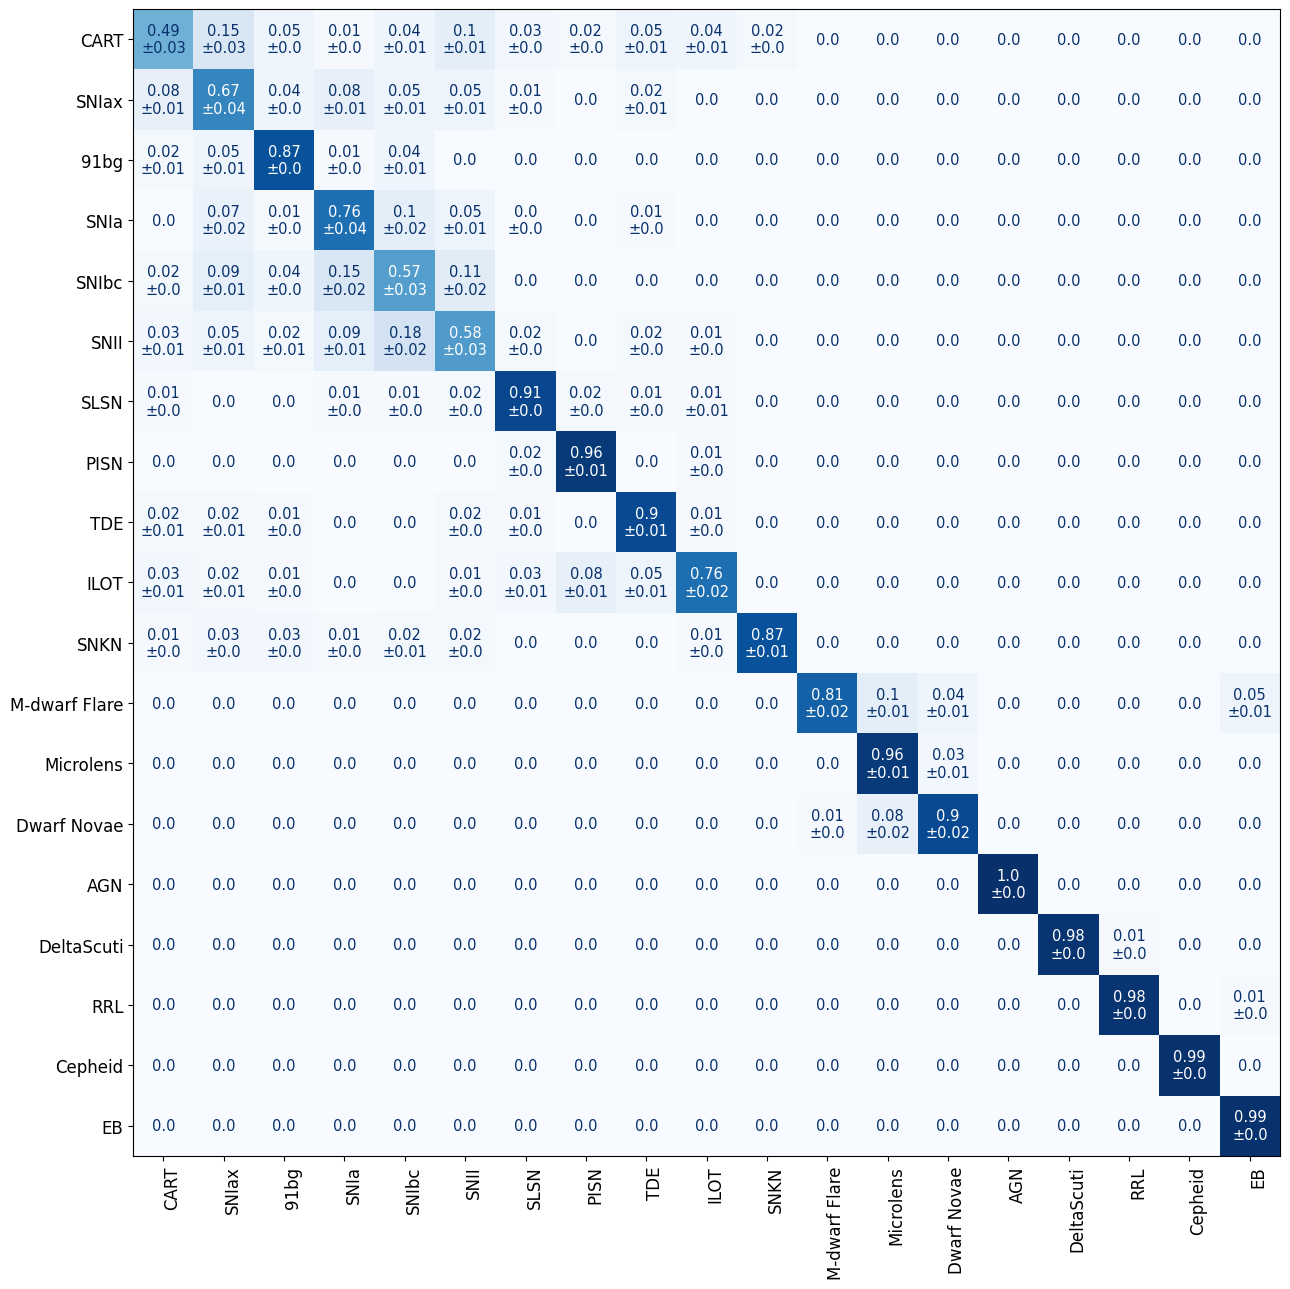

In [3]:

FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'

DEVICE = 'cuda:0'
DATASET = 'test'
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'

FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"

reports_1 = []
reports_2 = []
dfs = []
home = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/FF/LC_MD_FEAT/'


paths = [home + f'class_debug_v5_{i}' + '/' for i in range(5)]
for PATH in paths:

    test = InitCombinator(path_to_config_yaml=PATH,
                    lc_model= LightCurveTransformer,
                    tab_model= TabularTransformer,
                    classifier = MultimodalClassifier,
                    classifier_args={'use_lc':False,
                                     'use_tab':False,
                                     'use_mix':True},
                    arg_key='tab',
                    device = DEVICE)
    dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=32,datamodule_args=test.args.datamodule)
    dl.init_test_dataset()


    val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
    #print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
    dfs.append(pd.DataFrame(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=True)).T.drop(columns = ['support']))

    #test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)
    for_cm_true = np.vectorize({value:key for key, value in ELASTICC_TAXONOMY().items()}.get)([int(x) for x in val_true])
    for_cm_pred = np.vectorize({value:key for key, value in ELASTICC_TAXONOMY().items()}.get)([int(x) for x in np.argmax(val_preds, axis = -1)])
    reports_1.append((for_cm_true,for_cm_pred ))

matrices = []
for y_test, y_pred in reports_1:
    cm = confusion_matrix(y_test, y_pred,

                            labels=order_classes, normalize='true')
    matrices.append(cm)

# Calculando la media y la desviación estándar
mean_matrix_lc_md_feat = np.mean(matrices, axis=0)
std_matrix_lc_md_feat = np.std(matrices, axis=0)

fig = get_confusion_matrix(mean_matrix_lc_md_feat, std_matrix_lc_md_feat, order_classes)
#plt.show()
name = paths[0].split('/')[-2]
print(name)
fig.savefig("MATRICES/" + f"{name}.png")  # save before plt.show()


In [15]:
import pandas as pd

means = pd.concat([df.reset_index() for df in dfs]).groupby('index').mean()

In [16]:
stds = pd.concat([df.reset_index() for df in dfs]).groupby('index').std()


In [ ]:
np.mean([key['macro avg']['f1-score'] for key in reports_1])

TypeError: tuple indices must be integers or slices, not str

In [19]:
means.reset_index()

,index,precision,recall,f1-score
0,91bg,0.808804,0.838000,0.822699
1,AGN,0.995025,0.996000,0.995505
2,CART,0.703330,0.332667,0.449014
3,Cepheid,0.995338,0.992667,0.993995
4,DeltaScuti,0.993944,0.983667,0.988776
5,Dwarf Novae,0.913206,0.889000,0.900467
6,EB,0.869459,0.996333,0.928367
7,ILOT,0.918932,0.673000,0.776844
8,M-dwarf Flare,0.982513,0.704333,0.819750
9,Microlens,0.806690,0.948000,0.870411


NameError: name 'means' is not defined

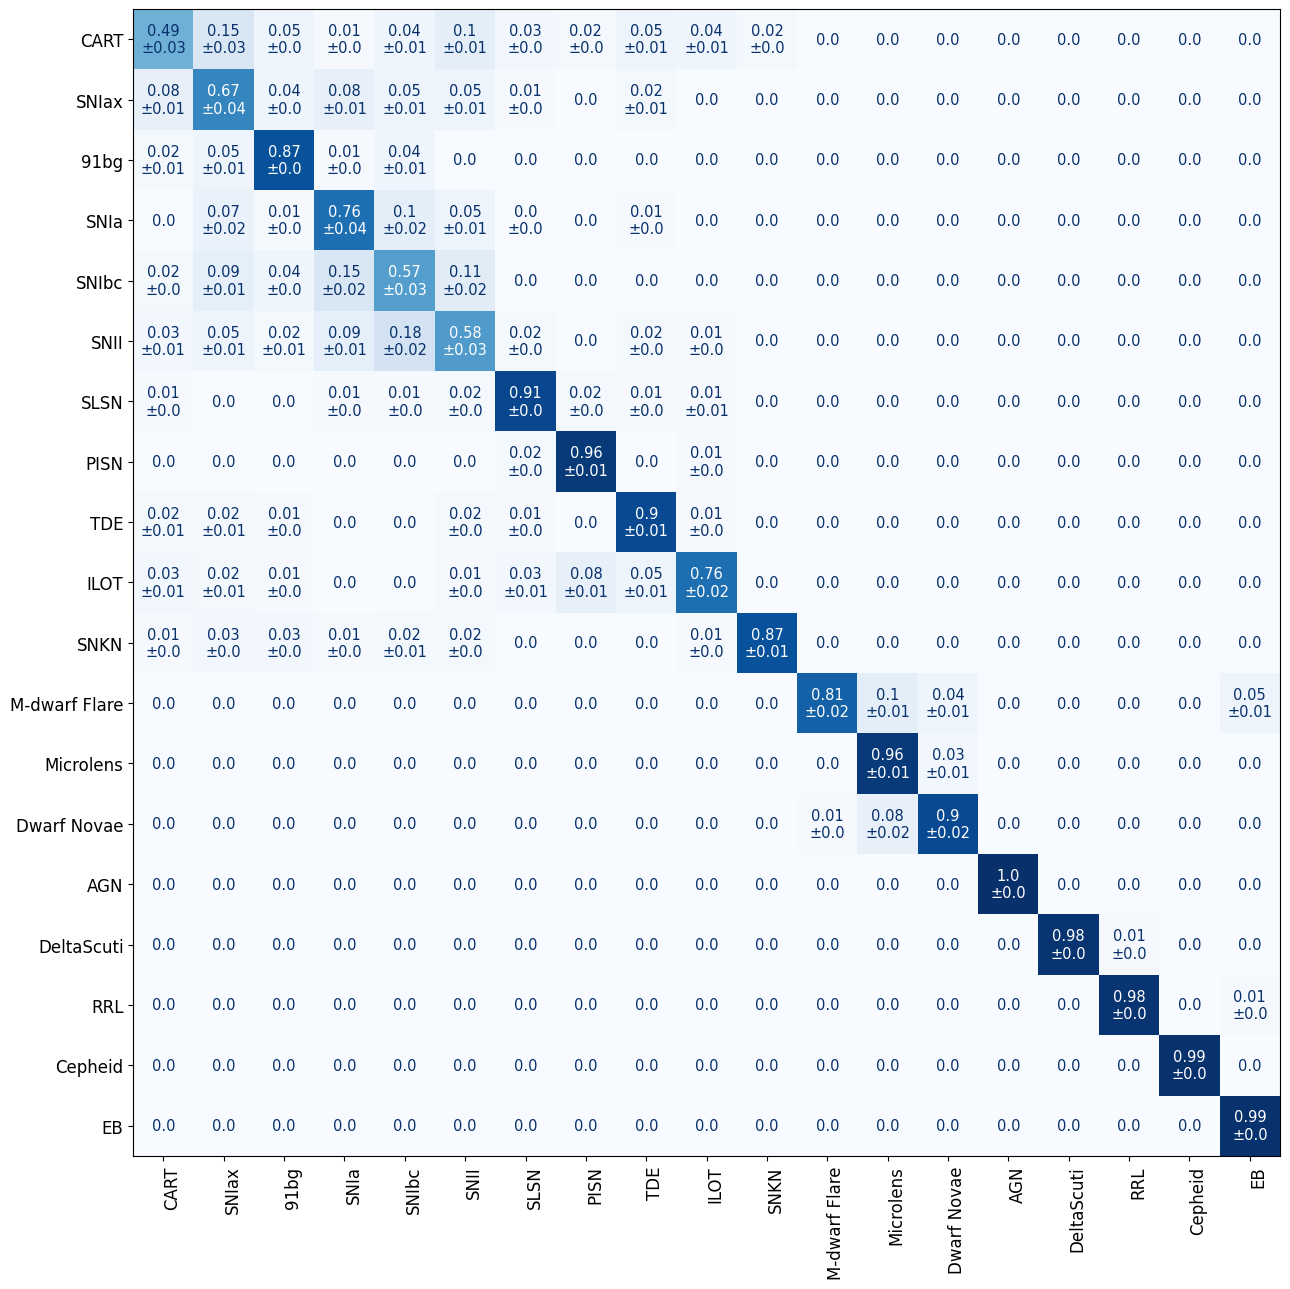

In [4]:

matrices = []
for y_test, y_pred in reports_1:
    cm = confusion_matrix(y_test, y_pred,

                            labels=order_classes, normalize='true')
    matrices.append(cm)

# Calculando la media y la desviación estándar
mean_matrix_lc_md_feat = np.mean(matrices, axis=0)
std_matrix_lc_md_feat = np.std(matrices, axis=0)

fig = get_confusion_matrix(mean_matrix_lc_md_feat, std_matrix_lc_md_feat, order_classes)
plt.title(f'LC + MD + FEAT | Test | F1-Score (macro): {means.iloc[20]['f1-score'].round(4).astype(str) +' +/-'+ stds.iloc[20]['f1-score'].round(4).astype(str)}')
#plt.show()
name = paths[0].split('/')[-2]

fig.savefig("MATRICES/" + f"{name}.png")  # save before plt.show()